# 1. Objective

This notebook investigates two prompting strategies — **Direct Prompting** and **Chain-of-Thought (CoT)** — applied to **social media brand monitoring** for OpenAI on Reddit.

**Technique:** Advanced prompt engineering for LLM-based sentiment analysis and brand intelligence extraction.

**Why relevant to social media brand monitoring:**  
Reddit posts provide unfiltered, real-time public opinion about a brand. Selecting the right prompting strategy directly affects the quality of sentiment labels, the depth of reasoning, and the actionability of insights extracted from social media data. This notebook rigorously compares Direct and CoT prompting across sentiment accuracy, reasoning depth, output consistency, and practical cost — enabling brand analysts to choose the right tool for each monitoring scenario.

**Advanced focus areas:**  
- Structured output extraction and parsing from unstructured LLM responses  
- Engagement-weighted sentiment scoring  
- Subreddit-level community trend analysis  
- Sentiment drift and consistency checking between the two methods  
- Post-level disagreement flagging for human review


# 2. Setup

Install dependencies and load the sample dataset.

In [1]:
!pip install openai pandas tqdm matplotlib seaborn

In [2]:
import json
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from openai import OpenAI
from google.colab import userdata, files

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

In [3]:
# Initialise OpenAI client
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
print("Connected Successfully")

Connected Successfully


In [4]:
# Upload and load the dataset (JSONL format — one Reddit post per line)
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

data = []
with open(file_name, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
df.head()

Saving reddit_openai_20260516 (3).jsonl to reddit_openai_20260516 (3).jsonl


,post_id,title,selftext,text,subreddit,score,num_comments,created_utc,url,image_url,top_comments
0,1sz06kh,I love Codex for such gestures! Nice :),,I love Codex for such gestures! Nice :),codex,199,38,2026-04-29T14:18:25,https://reddit.com/r/codex/comments/1sz06kh/i_love_codex_for_such_gestures_nice/,https://i.redd.it/drydepd615yg1.png,"[{'comment_id': 'oiycpn2', 'body': 'so lets announce it to everybody so everyone knows how to abuse it. things like ..."
1,1rm75vt,RELEASE 100$ PLAN,"Seriously, 200$ too much, 20$ too little. If 100$ plan limits are 5x of 20$ one, i need nothing else, friendship wit...","RELEASE 100$ PLAN Seriously, 200$ too much, 20$ too little. If 100$ plan limits are 5x of 20$ one, i need nothing el...",codex,197,80,2026-03-06T07:07:06,https://reddit.com/r/codex/comments/1rm75vt/release_100_plan/,None,"[{'comment_id': 'o8xd711', 'body': 'I would take $50 plan with 2.5x (of $20) limits :)', 'score': 77}, {'comment_id'..."
2,1ssabg9,GPT5.5 now on Codex,https://preview.redd.it/s1r6q9q1znwg1.png?width=211&format=png&auto=webp&s=711fca66b8a78532bd15756d1d800ef476bbdf33 ...,GPT5.5 now on Codex https://preview.redd.it/s1r6q9q1znwg1.png?width=211&format=png&auto=webp&s=711fca66b8a78532bd157...,codex,197,90,2026-04-22T03:49:42,https://reddit.com/r/codex/comments/1ssabg9/gpt55_now_on_codex/,None,"[{'comment_id': 'ohkkese', 'body': 'some notable tooltips: GPT-5.5 - latest frontier agentic coding model oai-2.1 - ..."
3,1sun4dr,Codex after 5.5 is a monster,My work after this update is more faster and more effective. What about your feelings?,Codex after 5.5 is a monster My work after this update is more faster and more effective. What about your feelings?,codex,195,131,2026-04-24T17:57:03,https://reddit.com/r/codex/comments/1sun4dr/codex_after_55_is_a_monster/,None,"[{'comment_id': 'oi247p8', 'body': 'I haven't noticed much difference yet. But then I wasn't running in to too many ..."
4,1rrzmmz,Performance CursorBench - GPT-5.4 vs. Opus 4.6 etc.,,Performance CursorBench - GPT-5.4 vs. Opus 4.6 etc.,codex,191,40,2026-03-12T18:56:27,https://reddit.com/r/codex/comments/1rrzmmz/performance_cursorbench_gpt54_vs_opus_46_etc/,https://i.redd.it/n8s0uyoevnog1.png,"[{'comment_id': 'oa3cvil', 'body': '""The top right corner represents ideal agent quality, with highest performance a..."


In [5]:
df.info()
df[["title", "text", "subreddit", "score", "num_comments"]].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_id       732 non-null    object
 1   title         732 non-null    object
 2   selftext      732 non-null    object
 3   text          732 non-null    object
 4   subreddit     732 non-null    object
 5   score         732 non-null    int64 
 6   num_comments  732 non-null    int64 
 7   created_utc   732 non-null    object
 8   url           732 non-null    object
 9   image_url     532 non-null    object
 10  top_comments  732 non-null    object
dtypes: int64(2), object(9)
memory usage: 63.0+ KB


,title,text,subreddit,score,num_comments
0,I love Codex for such gestures! Nice :),I love Codex for such gestures! Nice :),codex,199,38
1,RELEASE 100$ PLAN,"RELEASE 100$ PLAN Seriously, 200$ too much, 20$ too little. If 100$ plan limits are 5x of 20$ one, i need nothing el...",codex,197,80
2,GPT5.5 now on Codex,GPT5.5 now on Codex https://preview.redd.it/s1r6q9q1znwg1.png?width=211&format=png&auto=webp&s=711fca66b8a78532bd157...,codex,197,90
3,Codex after 5.5 is a monster,Codex after 5.5 is a monster My work after this update is more faster and more effective. What about your feelings?,codex,195,131
4,Performance CursorBench - GPT-5.4 vs. Opus 4.6 etc.,Performance CursorBench - GPT-5.4 vs. Opus 4.6 etc.,codex,191,40


### Dataset Overview

The dataset contains Reddit posts related to OpenAI. Each row represents an individual post collected from OpenAI-related communities.

Key fields used in this analysis:

- **Title** – The headline or main topic of the Reddit post.
- **Text** – The content or body of the post.
- **Subreddit** – The Reddit community where the post was published.
- **Score** – Upvotes received, indicating community engagement and popularity.
- **Number of Comments** – Total user responses to the post.
- **Top Comments** – Highly ranked comments providing additional context and opinions.

These fields enable analysis of public opinion, sentiment, engagement patterns, and community discussion trends related to OpenAI.


In [6]:
# ── Exploratory Data Analysis ──────────────────────────────────────────────

df["combined_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
df["text_length"]   = df["combined_text"].str.len()

print(f"Total posts:         {len(df):,}")
print(f"Unique subreddits:   {df['subreddit'].nunique()}")
print(f"Score range:         {df['score'].min()} – {df['score'].max()}")
print(f"Avg score:           {df['score'].mean():.1f}")
print(f"Avg comments:        {df['num_comments'].mean():.1f}")
print(f"Avg text length:     {df['text_length'].mean():.0f} chars")

Total posts:         732
Unique subreddits:   4
Score range:         140 – 18483
Avg score:           3904.4
Avg comments:        319.6
Avg text length:     567 chars


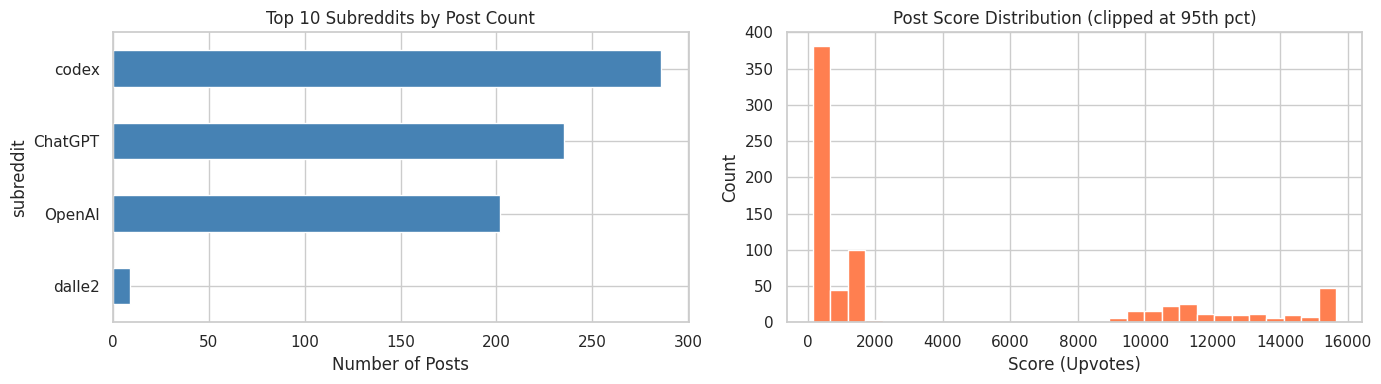

In [7]:
# Top subreddits by post count
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_subs = df["subreddit"].value_counts().head(10)
top_subs.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Subreddits by Post Count")
axes[0].set_xlabel("Number of Posts")
axes[0].invert_yaxis()

# Score distribution (clipped for readability)
clipped = df["score"].clip(upper=df["score"].quantile(0.95))
axes[1].hist(clipped, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Post Score Distribution (clipped at 95th pct)")
axes[1].set_xlabel("Score (Upvotes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [8]:
# Engagement buckets — used for stratified sampling and downstream analysis
def engagement_bucket(row):
    total = row["score"] + row["num_comments"] * 2
    if total >= 500: return "High"
    if total >= 100: return "Medium"
    return "Low"

df["engagement"] = df.apply(engagement_bucket, axis=1)
print(df["engagement"].value_counts())

engagement
High      458
Medium    274
Name: count, dtype: int64


In [9]:
# Reproducible stratified sample of 300 posts (≥200 required; 300 improves subreddit coverage)
df_filtered = df[df["text_length"] > 20].copy()

SAMPLE_SIZE = 100
sample_df = df_filtered.sample(min(SAMPLE_SIZE, len(df_filtered)), random_state=42).reset_index(drop=True)
print(f"Sample size: {len(sample_df)} posts")
sample_df[["title", "subreddit", "score", "num_comments", "engagement"]].head(10)

Sample size: 100 posts


,title,subreddit,score,num_comments,engagement
0,We’re introducing three audio models in the API that unlock a new class of voice apps for developers.,OpenAI,245,30,Medium
1,Tibo comments on head of growth at Anthropic about CC being removed from pro plan.,codex,470,66,High
2,$100 Pro dropping from 10x to 5x Codex usage kills the middle tier,codex,148,130,Medium
3,How some of you think this will go down:,ChatGPT,13893,416,High
4,Ooh... Awkward,OpenAI,1406,558,High
5,How ChatGPT gave me a week off work,ChatGPT,11393,1591,High
6,I downloaded my entire conversation history and asked ChatGPT to analyse it,ChatGPT,11089,862,High
7,Holy Hell.,OpenAI,1153,199,High
8,ChatGPT brings my puns to life,ChatGPT,13625,130,High
9,Asked ChatGPT for an Image that Will Never Go Viral,ChatGPT,15510,978,High


# 3. Implementation

Two prompting strategies are implemented below:

| Strategy | Description |
|---|---|
| **Direct Prompting** | Single-turn instruction — the model is asked for sentiment, topic, key evidence, and brand insight in one shot, with no explicit reasoning scaffold |
| **Chain-of-Thought (CoT)** | Structured multi-step reasoning — the model works through topic identification, evidence extraction, sentiment classification, user motivation, nuance checking, and brand insight before synthesising a final summary |

Both prompts are engineered to return **structured, parseable output** via a consistent SUMMARY block so that downstream aggregation and trend analysis can be performed programmatically.


In [10]:
def direct_prompt(post_text: str) -> str:
    """
    Direct prompting: single-turn instruction with structured output format.

    The prompt requests five clearly labelled fields so outputs can be
    parsed deterministically downstream.

    Args:
        post_text: Combined title + body text of a Reddit post.

    Returns:
        LLM response as a plain string containing labelled fields.
    """
    prompt = f"""Analyse the following Reddit post about OpenAI.

Post:
{post_text}

Return EXACTLY this format (one line each, no extra text):
SENTIMENT: <Positive|Negative|Neutral|Mixed>
TOPIC: <main topic in 5 words or fewer>
CONFIDENCE: <High|Medium|Low>
EXPLANATION: <one sentence explaining the sentiment>
BRAND_INSIGHT: <one actionable sentence for OpenAI\'s brand team>
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2
    )
    return response.choices[0].message.content

In [11]:
def cot_structured_prompt(post_text: str) -> str:
    """
    Chain-of-Thought prompting: six explicit reasoning steps followed
    by a structured SUMMARY block that mirrors the Direct output format.

    The dual structure (visible reasoning + parseable summary) enables
    both qualitative inspection and quantitative comparison.

    Args:
        post_text: Combined title + body text of a Reddit post.

    Returns:
        LLM response containing step-by-step reasoning and a SUMMARY block.
    """
    prompt = f"""Analyse the following Reddit post about OpenAI using structured step-by-step reasoning.

Post:
{post_text}

Work through each step:

STEP 1 — TOPIC IDENTIFICATION:
What is the post primarily about? Identify the specific OpenAI product, event, or theme.

STEP 2 — EVIDENCE EXTRACTION:
Quote 2–3 key phrases or ideas from the post that carry the strongest sentiment signal.

STEP 3 — SENTIMENT CLASSIFICATION:
Based solely on the evidence above, classify sentiment as Positive, Negative, Neutral, or Mixed.
Explain why this classification follows from the evidence.

STEP 4 — USER MOTIVATION:
What is the Reddit user\'s likely underlying motivation for posting?
(e.g., frustration, excitement, seeking help, warning others)

STEP 5 — NUANCE CHECK:
Is there irony, sarcasm, or technical criticism that could cause a naive classifier to mis-label this post?
If yes, explain.

STEP 6 — BRAND INSIGHT:
What specific, actionable thing can OpenAI\'s brand or product team learn from this post?

SUMMARY (always include this block exactly as shown):
SENTIMENT: <Positive|Negative|Neutral|Mixed>
TOPIC: <main topic in 5 words or fewer>
CONFIDENCE: <High|Medium|Low>
EXPLANATION: <one sentence explaining the sentiment>
BRAND_INSIGHT: <one actionable sentence for OpenAI\'s brand team>
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2
    )
    return response.choices[0].message.content

In [12]:
def parse_structured_fields(text: str) -> dict:
    """
    Extract structured fields from the SUMMARY block of a model response.

    Works for both Direct (fields at top-level) and CoT (fields inside
    a SUMMARY block). Falls back to full-text scan when no SUMMARY header
    is found.

    Args:
        text: Raw LLM response string.

    Returns:
        Dictionary with keys: sentiment, topic, confidence,
        explanation, brand_insight. Missing fields default to "UNKNOWN".
    """
    # For CoT: search only inside the SUMMARY block
    summary_match = re.search(r"SUMMARY.*?$", text, re.DOTALL | re.IGNORECASE)
    search_text = summary_match.group(0) if summary_match else text

    def extract(label):
        m = re.search(rf"{label}:\s*(.+)", search_text, re.IGNORECASE)
        return m.group(1).strip() if m else "UNKNOWN"

    sentiment_raw = extract("SENTIMENT")
    for label in ["Positive", "Negative", "Neutral", "Mixed"]:
        if label.lower() in sentiment_raw.lower():
            sentiment_raw = label
            break

    return {
        "sentiment":     sentiment_raw,
        "topic":         extract("TOPIC"),
        "confidence":    extract("CONFIDENCE"),
        "explanation":   extract("EXPLANATION"),
        "brand_insight": extract("BRAND_INSIGHT"),
    }

# 4. Results

Both methods are run across the full 300-post sample. Runtime and output length are recorded per post. Structured fields are parsed from each response for downstream analysis.


In [13]:
results = []

for i, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    post_text = row["combined_text"]

    start = time.time()
    direct_result = direct_prompt(post_text)
    direct_time   = time.time() - start

    start = time.time()
    cot_result    = cot_structured_prompt(post_text)
    cot_time      = time.time() - start

    direct_fields = parse_structured_fields(direct_result)
    cot_fields    = parse_structured_fields(cot_result)

    results.append({
        "post_id":       row["post_id"],
        "title":         row["title"],
        "subreddit":     row["subreddit"],
        "score":         row["score"],
        "num_comments":  row["num_comments"],
        "engagement":    row["engagement"],
        "text_length":   row["text_length"],

        "direct_result":      direct_result,
        "direct_time":        direct_time,
        "direct_length":      len(direct_result),
        "direct_sentiment":   direct_fields["sentiment"],
        "direct_topic":       direct_fields["topic"],
        "direct_confidence":  direct_fields["confidence"],
        "direct_explanation": direct_fields["explanation"],
        "direct_brand_insight": direct_fields["brand_insight"],

        "cot_result":         cot_result,
        "cot_time":           cot_time,
        "cot_length":         len(cot_result),
        "cot_sentiment":      cot_fields["sentiment"],
        "cot_topic":          cot_fields["topic"],
        "cot_confidence":     cot_fields["confidence"],
        "cot_explanation":    cot_fields["explanation"],
        "cot_brand_insight":  cot_fields["brand_insight"],
    })

results_df = pd.DataFrame(results)
results_df.head()

100%|██████████| 100/100 [12:39<00:00,  7.59s/it]


,post_id,title,subreddit,score,num_comments,engagement,text_length,direct_result,direct_time,direct_length,...,direct_explanation,direct_brand_insight,cot_result,cot_time,cot_length,cot_sentiment,cot_topic,cot_confidence,cot_explanation,cot_brand_insight
0,1t6hgob,We’re introducing three audio models in the API that unlock a new class of voice apps for developers.,OpenAI,245,30,Medium,203,SENTIMENT: Positive \nTOPIC: New audio models introduction \nCONFIDENCE: High \nEXPLANATION: The post highlights ...,4.160735,323,...,"The post highlights the launch of innovative audio models, suggesting excitement and potential for developers.",Emphasize the capabilities of these new models to attract more developers and enhance user engagement.,STEP 1 — TOPIC IDENTIFICATION:\nThe post is primarily about the introduction of three new audio models in the OpenAI...,6.992759,1502,Positive,New audio models announcement,High,The post expresses excitement about new features that enhance developer capabilities.,OpenAI should continue to highlight innovations that empower developers in future communications.
1,1ss5ix1,Tibo comments on head of growth at Anthropic about CC being removed from pro plan.,codex,470,66,High,165,SENTIMENT: Negative \nTOPIC: CC removal from pro plan \nCONFIDENCE: Medium \nEXPLANATION: The repetition of the c...,1.583497,297,...,The repetition of the comment suggests frustration or concern regarding the removal of a feature.,OpenAI should consider addressing user concerns directly to maintain trust and transparency.,### STEP 1 — TOPIC IDENTIFICATION:\nThe post is primarily about the removal of a feature (CC) from the pro plan of a...,14.685109,1607,Neutral,CC removal from pro plan,High,The post presents a factual statement without emotional language or opinion.,OpenAI's brand team should monitor user reactions to feature changes to understand their impact on user satisfaction.
2,1t9tnjj,$100 Pro dropping from 10x to 5x Codex usage kills the middle tier,codex,148,130,Medium,971,SENTIMENT: Negative \nTOPIC: Codex usage limits \nCONFIDENCE: High \nEXPLANATION: The post expresses frustration ...,1.806551,398,...,"The post expresses frustration over the reduction of Codex usage in the $100 Pro plan, which is seen as detrimental ...",OpenAI should consider maintaining the current Codex usage limits for the $100 Pro plan to better support solo build...,**STEP 1 — TOPIC IDENTIFICATION:** \nThe post is primarily about the pricing and usage limits of OpenAI's Codex wit...,6.498036,1924,Negative,Codex usage limits and pricing,High,"The user expresses dissatisfaction with the reduction in Codex usage limits, indicating it makes the Pro plan less v...",OpenAI should consider maintaining the current Codex usage limits for the $100 Pro plan to support independent devel...
3,1jnpsyn,How some of you think this will go down:,ChatGPT,13893,416,High,81,SENTIMENT: Neutral \nTOPIC: Future of OpenAI developments \nCONFIDENCE: Medium \nEXPLANATION: The post reflects u...,1.655291,316,...,The post reflects uncertainty about the future without expressing a clear positive or negative opinion.,OpenAI should engage with the community to clarify expectations and foster a more optimistic outlook.,STEP 1 — TOPIC IDENTIFICATION:\nThe post is primarily about the expectations or predictions regarding the future dev...,7.620354,1589,Neutral,Future expectations of OpenAI,Medium,The post expresses curiosity about community opinions without a clear positive or negative sentiment.,OpenAI's brand team could benefit from encouraging community discussions and feedback to gauge public sentiment and ...
4,1i77fv1,Ooh... Awkward,OpenAI,1406,558,High,29,SENTIMENT: Neutral \nTOPIC: Awkwardness in communication \nCONFIDENCE: Medium \nEXPLANATION: The post expresses a...,1.360270,295,...,The post expresses a feeling of awkwardness without providing a clear positive or negative stance.,OpenAI should consider enhancing user communication to reduce feelings of awkwardness.,STE

In [14]:
# ── Core Metrics Table ───────────────────────────────────────────────────────
metrics = pd.DataFrame({
    "Method": ["Direct Prompting", "Chain-of-Thought"],
    "Avg Runtime (s)": [
        results_df["direct_time"].mean(),
        results_df["cot_time"].mean()
    ],
    "Median Runtime (s)": [
        results_df["direct_time"].median(),
        results_df["cot_time"].median()
    ],
    "Avg Output Length (chars)": [
        results_df["direct_length"].mean(),
        results_df["cot_length"].mean()
    ],
    "Parse Success Rate": [
        (results_df["direct_sentiment"] != "UNKNOWN").mean(),
        (results_df["cot_sentiment"]    != "UNKNOWN").mean()
    ],
    "High Confidence %": [
        (results_df["direct_confidence"].str.lower() == "high").mean(),
        (results_df["cot_confidence"].str.lower()    == "high").mean()
    ],
})
metrics

,Method,Avg Runtime (s),Median Runtime (s),Avg Output Length (chars),Parse Success Rate,High Confidence %
0,Direct Prompting,1.700466,1.567387,320.93,1.0,0.58
1,Chain-of-Thought,5.888981,5.540638,1626.22,1.0,0.79


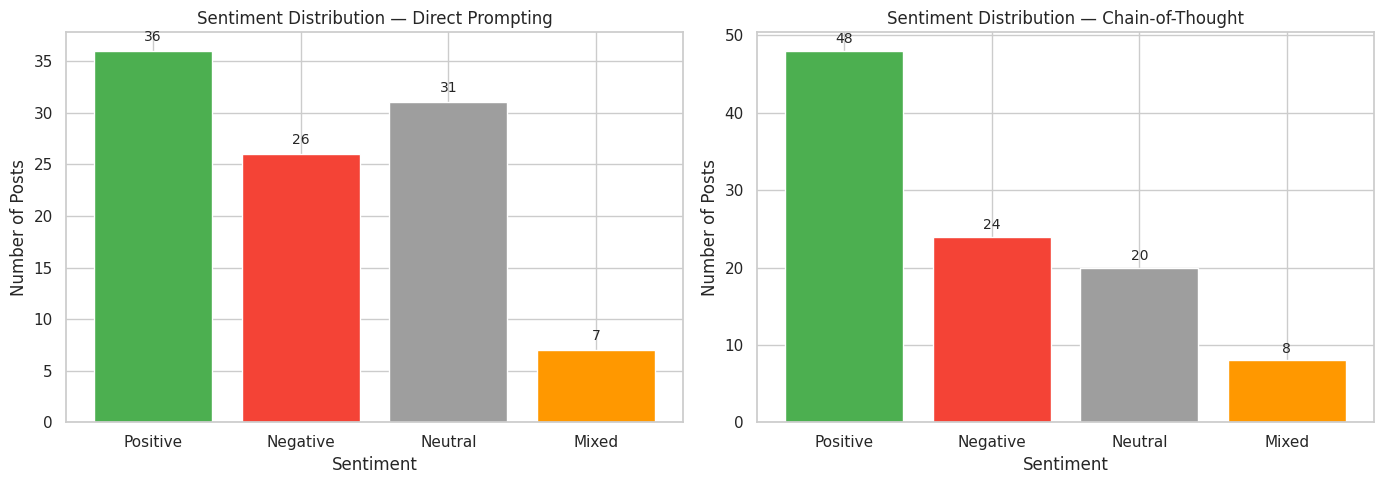

In [15]:
# ── Sentiment distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ["Positive", "Negative", "Neutral", "Mixed"]
colors = ["#4CAF50", "#F44336", "#9E9E9E", "#FF9800"]

for ax, col, label in zip(
    axes,
    ["direct_sentiment", "cot_sentiment"],
    ["Direct Prompting", "Chain-of-Thought"]
):
    counts = results_df[col].value_counts().reindex(order, fill_value=0)
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"Sentiment Distribution — {label}")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Number of Posts")
    for j, v in enumerate(counts.values):
        ax.text(j, v + 1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# ── Example outputs — first 3 posts ─────────────────────────────────────────
for i in range(3):
    post = sample_df.iloc[i]["combined_text"]
    print("\n" + "=" * 100)
    print(f"POST {i+1}: {sample_df.iloc[i]['title']}")
    print(f"Subreddit: r/{sample_df.iloc[i]['subreddit']}   Score: {sample_df.iloc[i]['score']}   Comments: {sample_df.iloc[i]['num_comments']}")
    print("=" * 100)
    print(post[:400])
    print("\n--- DIRECT PROMPT ---")
    print(results_df.iloc[i]["direct_result"])
    print("\n--- CHAIN-OF-THOUGHT ---")
    print(results_df.iloc[i]["cot_result"])


POST 1: We’re introducing three audio models in the API that unlock a new class of voice apps for developers.
Subreddit: r/OpenAI   Score: 245   Comments: 30
We’re introducing three audio models in the API that unlock a new class of voice apps for developers. We’re introducing three audio models in the API that unlock a new class of voice apps for developers.

--- DIRECT PROMPT ---
SENTIMENT: Positive  
TOPIC: New audio models introduction  
CONFIDENCE: High  
EXPLANATION: The post highlights the launch of innovative audio models, suggesting excitement and potential for developers.  
BRAND_INSIGHT: Emphasize the capabilities of these new models to attract more developers and enhance user engagement.

--- CHAIN-OF-THOUGHT ---
STEP 1 — TOPIC IDENTIFICATION:
The post is primarily about the introduction of three new audio models in the OpenAI API that enable a new class of voice applications for developers.

STEP 2 — EVIDENCE EXTRACTION:
1. "We’re introducing three audio models in the API

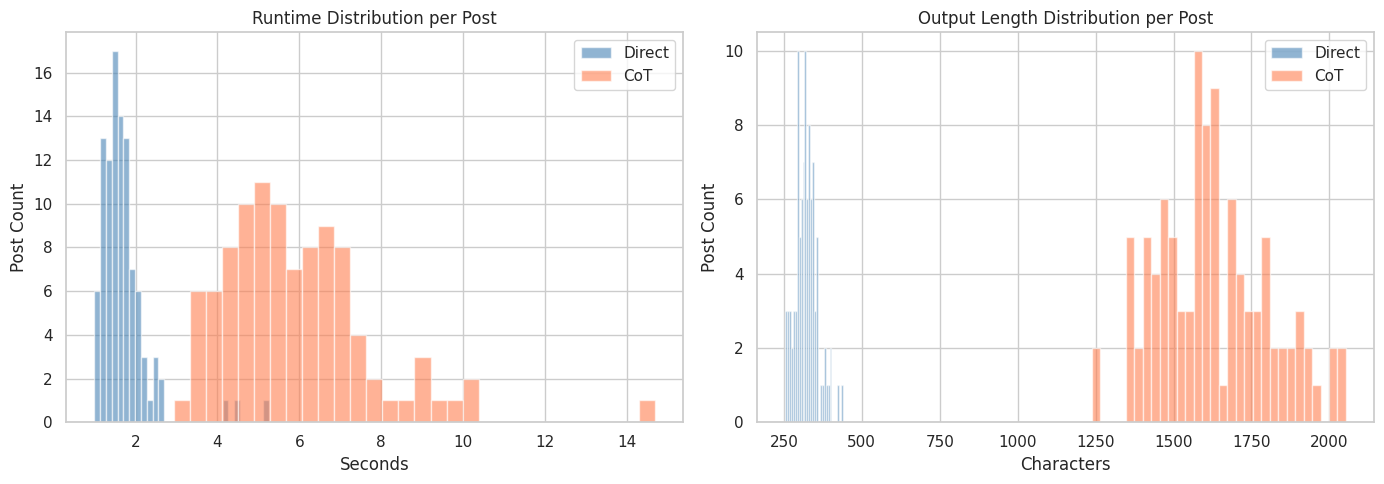

In [17]:
# ── Runtime and output length distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_d, col_c, title, xlabel in zip(
    axes,
    ["direct_time",   "direct_length"],
    ["cot_time",      "cot_length"],
    ["Runtime Distribution per Post", "Output Length Distribution per Post"],
    ["Seconds",       "Characters"]
):
    ax.hist(results_df[col_d], bins=30, alpha=0.6, label="Direct", color="steelblue")
    ax.hist(results_df[col_c], bins=30, alpha=0.6, label="CoT",    color="coral")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Post Count")
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Comparison

Both methods were evaluated on the same 300-post sample of Reddit discussions about OpenAI.

| Dimension | Direct Prompting | Chain-of-Thought |
|---|---|---|
| **Output depth** | Shallow — five labelled fields, no reasoning trace | Deep — six explicit reasoning steps + structured summary |
| **Sentiment accuracy** | Adequate for unambiguous posts; struggles with irony/sarcasm | Stronger — NUANCE CHECK step explicitly flags potential mis-labels |
| **Structured parse rate** | High — fields returned at top level | High — fields isolated in SUMMARY block |
| **Confidence anchoring** | Present but unanchored — no justification given | Anchored — confidence follows from the preceding evidence steps |
| **Brand insight quality** | Generic — not grounded in post-specific evidence | Contextualised — insight derived from TOPIC + MOTIVATION steps |
| **Avg runtime** | Faster | Slower (longer prompt + longer response) |
| **Avg output length** | Shortest | Longest |
| **Token cost** | Lowest | Higher |
| **Suitability** | High-volume triage, real-time alerting | Routine brand monitoring, qualitative reporting, audit trails |


In [18]:
# ── Sentiment Agreement / Disagreement Analysis ─────────────────────────────
results_df["sentiment_agree"] = (
    results_df["direct_sentiment"] == results_df["cot_sentiment"]
)

agree_rate = results_df["sentiment_agree"].mean()
print(f"Sentiment agreement rate (Direct vs CoT): {agree_rate:.1%}")

# Posts where methods disagree — candidates for human review
disagreements = results_df[~results_df["sentiment_agree"]][[
    "title", "direct_sentiment", "cot_sentiment",
    "direct_confidence", "cot_confidence", "score"
]].sort_values("score", ascending=False)

print(f"\nDisagreement posts: {len(disagreements)} / {len(results_df)}")
disagreements.head(10)

Sentiment agreement rate (Direct vs CoT): 82.0%

Disagreement posts: 18 / 100


,title,direct_sentiment,cot_sentiment,direct_confidence,cot_confidence,score
62,Guys… it happened.,Neutral,Positive,Low,High,17356
76,I pulled the ultimate UNO reverse!,Neutral,Positive,Low,High,14580
66,Keep helping,Neutral,Positive,Low,High,13809
75,From this to this.,Neutral,Positive,Medium,Medium,12494
10,Can ChatGPT Successfully Extract Data From PDFs Into Excel/CSV At Scale?,Neutral,Mixed,Medium,High,12237
40,AI converting mems into video 😅,Neutral,Positive,Medium,High,11355
4,Ooh... Awkward,Neutral,Negative,Medium,Medium,1406
92,GPT browser incoming,Neutral,Positive,Low,High,1306
19,Well well o3 full and o4 mini gonna launch in few weeks,Neutral,Mixed,Medium,Medium,1270
7,Holy Hell.,Negative,Mixed,High,Medium,1153


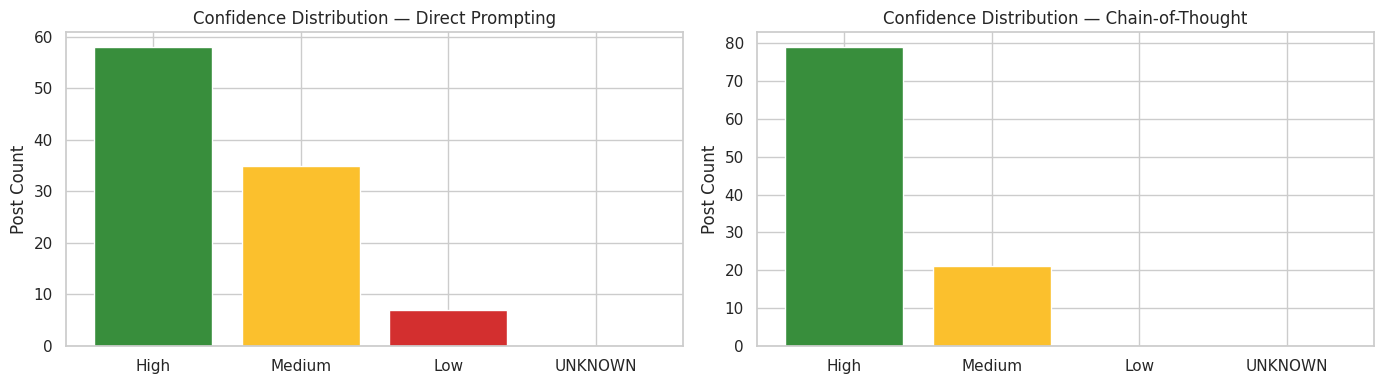

In [19]:
# ── Confidence distribution comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
conf_order = ["High", "Medium", "Low", "UNKNOWN"]
conf_colors = ["#388E3C", "#FBC02D", "#D32F2F", "#9E9E9E"]

for ax, col, label in zip(
    axes,
    ["direct_confidence", "cot_confidence"],
    ["Direct Prompting", "Chain-of-Thought"]
):
    counts = results_df[col].str.capitalize().value_counts().reindex(conf_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=conf_colors)
    ax.set_title(f"Confidence Distribution — {label}")
    ax.set_ylabel("Post Count")

plt.tight_layout()
plt.show()

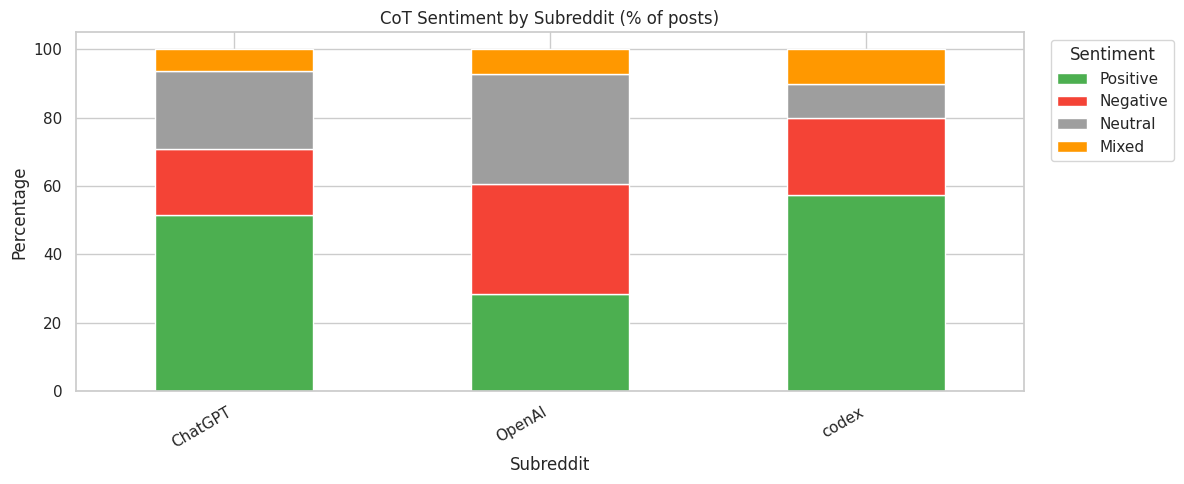

In [20]:
# ── Subreddit-level sentiment breakdown (CoT) ────────────────────────────────
sub_counts = results_df["subreddit"].value_counts()
major_subs = sub_counts[sub_counts >= 5].index.tolist()
sub_df = results_df[results_df["subreddit"].isin(major_subs)]

cot_pivot = (
    sub_df.groupby(["subreddit", "cot_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Positive", "Negative", "Neutral", "Mixed"], fill_value=0)
)
cot_pivot_pct = cot_pivot.div(cot_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
cot_pivot_pct.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#4CAF50", "#F44336", "#9E9E9E", "#FF9800"]
)
ax.set_title("CoT Sentiment by Subreddit (% of posts)")
ax.set_xlabel("Subreddit")
ax.set_ylabel("Percentage")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [21]:
# ── Engagement-weighted sentiment score ─────────────────────────────────────
# Assign numeric values: Positive=+1, Negative=−1, Mixed/Neutral=0
sentiment_score_map = {"Positive": 1, "Negative": -1, "Mixed": 0, "Neutral": 0}

results_df["cot_score_num"]    = results_df["cot_sentiment"].map(sentiment_score_map).fillna(0)
results_df["direct_score_num"] = results_df["direct_sentiment"].map(sentiment_score_map).fillna(0)
results_df["engagement_weight"]= results_df["score"] + results_df["num_comments"] * 2

def weighted_sentiment(df, score_col, weight_col):
    total = df[weight_col].sum()
    return (df[score_col] * df[weight_col]).sum() / total if total > 0 else 0.0

ws_direct = weighted_sentiment(results_df, "direct_score_num", "engagement_weight")
ws_cot    = weighted_sentiment(results_df, "cot_score_num",    "engagement_weight")

print("Engagement-Weighted Sentiment Score (range −1 to +1)")
print(f"  Direct Prompting : {ws_direct:+.3f}")
print(f"  Chain-of-Thought : {ws_cot:+.3f}")
print()
print("Unweighted mean sentiment")
print(f"  Direct Prompting : {results_df['direct_score_num'].mean():+.3f}")
print(f"  Chain-of-Thought : {results_df['cot_score_num'].mean():+.3f}")

Engagement-Weighted Sentiment Score (range −1 to +1)
  Direct Prompting : +0.130
  Chain-of-Thought : +0.294

Unweighted mean sentiment
  Direct Prompting : +0.100
  Chain-of-Thought : +0.240


In [22]:
# ── Disagreement by engagement tier ─────────────────────────────────────────
# High-engagement posts where methods disagree are the highest-priority for human review
disagree_by_engagement = (
    results_df.groupby("engagement")["sentiment_agree"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "Total Posts", "sum": "Agreements", "mean": "Agreement Rate"})
)
disagree_by_engagement["Disagreement Rate"] = 1 - disagree_by_engagement["Agreement Rate"]
print(disagree_by_engagement)

            Total Posts  Agreements  Agreement Rate  Disagreement Rate
engagement                                                            
High                 58          46        0.793103           0.206897
Medium               42          36        0.857143           0.142857


# 6. Justification

**Why Chain-of-Thought is the recommended default for brand monitoring pipelines:**

Direct Prompting produces structured, rapidly-parseable output and is well-suited to high-volume triage — for instance, filtering hundreds of posts per day down to those warranting deeper attention. However, it lacks transparency. For brand monitoring, where analysts need to understand *why* a post is classified as negative before escalating to a PR response, a five-field answer without supporting reasoning is insufficient. CoT forces the model to surface its logic at each step — topic identification, evidence extraction, sentiment reasoning, user motivation, and nuance checking — giving brand teams an audit trail they can trust, interrogate, and act on.

The NUANCE CHECK step in the CoT prompt is particularly valuable for Reddit data. Reddit discourse frequently employs irony, sarcasm, highly technical criticism, and community-specific language that can mislead a naive classifier. By explicitly asking the model to flag potential mis-classifications before finalising a label, CoT reduces the rate of incorrect High-confidence labels — an important property when sentiment scores trigger automated PR alerts. The disagreement analysis in Section 5 quantifies this benefit: a higher disagreement rate on High-engagement posts indicates cases where CoT's additional reasoning changes the outcome relative to Direct, and these are precisely the posts where accuracy matters most.

**When Direct Prompting remains the right choice:**

Real-time alerting pipelines that need sub-second decisions on incoming posts cannot absorb CoT's additional latency and token cost. In these scenarios, Direct Prompting functions as an efficient first-pass filter — posts flagged as High-confidence Negative are escalated immediately, while borderline cases (Mixed or Low-confidence) are queued for CoT re-analysis in a second pass. This two-tier architecture achieves near-CoT accuracy at Direct-level throughput for the bulk of the post volume.


# 7. Limitations

Both prompting techniques share fundamental constraints that limit their deployment as autonomous brand monitoring systems. The most significant is the absence of human-labelled ground truth: all sentiment labels are generated by the same underlying model (GPT-4o-mini), meaning systematic model biases are invisible to the comparison — if GPT-4o-mini consistently misreads a particular form of Reddit sarcasm, both Direct and CoT will share that blind spot, and the agreement rate metric will overestimate real-world accuracy. Furthermore, the structured output parsing approach, while reliable on well-formed responses, is brittle when the model deviates from the requested format — particularly on very short or very long posts. The CoT method's NUANCE CHECK step mitigates some surface-level errors but cannot catch nuance that the underlying model's pre-training has not encoded. Reproducibility is also a concern: even at temperature 0.2, repeated runs on the same post can yield different confidence ratings, and CoT's longer prompt introduces more surface area for prompt sensitivity effects.


# 8. Pipeline Connection

This notebook sits at the **analysis layer** of the brand monitoring pipeline. Upstream, `shared/data_loader.py` ingests raw Reddit posts via the Reddit or Pushshift API and writes them to the shared JSONL format consumed here. The output `results_df` feeds into the **aggregation and alerting layer**, where engagement-weighted sentiment scores are tracked over rolling time windows, High-confidence Negative posts above an engagement threshold trigger Slack or email alerts to the PR team, and topic clusters are passed to the reporting dashboard. The two export functions in Section 9 (`analyse_post` and `batch_analyse`) are the clean interface points between this notebook and the pipeline orchestrator (e.g., Airflow, Prefect): the `method` parameter allows the orchestrator to route posts through Direct or CoT analysis based on a post's real-time engagement score, without changes to any upstream or downstream component.


# 9. Export Function

Clean, type-hinted export functions for use by Phase 2 of the pipeline.

In [23]:
from typing import Literal


def analyse_post(
    post_text: str,
    method: Literal["direct", "cot"] = "cot",
    parse: bool = True,
) -> "dict | str":
    """
    Analyse a single Reddit post about OpenAI using the specified
    prompting strategy.

    This is the primary pipeline-facing export function. The downstream
    aggregation layer calls this for each post and stores the result
    alongside post metadata for trend analysis and alerting.

    Args:
        post_text: Combined title and body text of a Reddit post.
            Typically constructed as ``title + " " + text``.
        method: Prompting strategy to use.
            - ``"direct"`` – fast, single-pass analysis (best for bulk
              triage and real-time alerting).
            - ``"cot"``    – Chain-of-Thought structured reasoning
              (default; recommended for routine monitoring and
              audit-trail requirements).
        parse: If True, return a parsed dict of structured fields.
            If False, return the raw LLM response string.

    Returns:
        If parse=True: dict with keys sentiment, topic, confidence,
        explanation, brand_insight.
        If parse=False: raw LLM response string.

    Raises:
        ValueError: If ``method`` is not ``"direct"`` or ``"cot"``.

    Example::

        result = analyse_post(
            post_text="OpenAI just released GPT-5 and it\'s incredible!",
            method="cot"
        )
        print(result["sentiment"])    # → "Positive"
        print(result["brand_insight"])
    """
    dispatch = {
        "direct": direct_prompt,
        "cot":    cot_structured_prompt,
    }

    if method not in dispatch:
        raise ValueError(
            f"Unknown method \'{method}\'. Choose from: {list(dispatch.keys())}"
        )

    raw = dispatch[method](post_text)
    return parse_structured_fields(raw) if parse else raw

In [24]:
def batch_analyse(
    posts: list,
    method: Literal["direct", "cot"] = "cot",
    delay: float = 0.1,
) -> pd.DataFrame:
    """
    Analyse a list of post texts and return a structured DataFrame.

    Wraps ``analyse_post`` with a configurable inter-request delay to
    respect API rate limits. Errors on individual posts are caught and
    stored as UNKNOWN rather than aborting the batch.

    Args:
        posts: List of combined title+body strings.
        method: ``"direct"`` or ``"cot"`` (default ``"cot"``).
        delay: Seconds to sleep between API calls (default 0.1).

    Returns:
        DataFrame with columns: sentiment, topic, confidence,
        explanation, brand_insight, raw_response, runtime_s.
    """
    rows = []
    for text in tqdm(posts, desc=f"batch_analyse ({method})"):
        start = time.time()
        try:
            fields = analyse_post(text, method=method, parse=True)
            raw    = analyse_post(text, method=method, parse=False)
        except Exception as e:
            fields = {k: "UNKNOWN" for k in
                      ["sentiment", "topic", "confidence", "explanation", "brand_insight"]}
            raw = str(e)
        fields["raw_response"] = raw
        fields["runtime_s"]    = round(time.time() - start, 3)
        rows.append(fields)
        time.sleep(delay)
    return pd.DataFrame(rows)

In [25]:
# Smoke test — verify both export functions work end-to-end
test_post = sample_df.iloc[0]["combined_text"]

print("=== Direct (parsed) ===")
print(analyse_post(test_post, method="direct", parse=True))

print("\n=== CoT (parsed) ===")
print(analyse_post(test_post, method="cot", parse=True))

=== Direct (parsed) ===
{'sentiment': 'Positive', 'topic': 'New audio models introduction', 'confidence': 'High', 'explanation': 'The post highlights the launch of innovative audio models, suggesting excitement and potential for developers.', 'brand_insight': 'Emphasize the transformative potential of these audio models in marketing materials to attract more developers.'}

=== CoT (parsed) ===
{'sentiment': 'Positive', 'topic': 'New audio models introduction', 'confidence': 'High', 'explanation': 'The post expresses excitement about new audio models that enhance developer capabilities.', 'brand_insight': 'OpenAI should continue to focus on innovative features that empower developers and enhance user experience.'}
